In [62]:
import pandas as pd

#importando padrão
df_stones = pd.read_excel("dataset_rolling_stones.xlsx")
df_stones.head()

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,0.0824,0.463,0.993,0.996000,0.932,-12913.0,0.1100,118001.0,0.0302,33,48640
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,0.4370,0.326,0.965,0.233000,0.961,-4803.0,0.0759,131455.0,0.3180,34,253173
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,0.4160,0.386,0.969,0.400000,0.956,-4936.0,0.1150,130066.0,0.3130,34,263160
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,0.5670,0.369,0.985,0.000107,0.895,-5535.0,0.1930,132994.0,0.1470,32,305880
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,0.4000,0.303,0.969,0.055900,0.966,-5098.0,0.0930,130533.0,0.2060,32,305106


In [63]:
#tipo de coluna
df_stones.info()

<class 'pandas.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   name              1610 non-null   str           
 1   album             1610 non-null   str           
 2   release_date      1610 non-null   datetime64[us]
 3   track_number      1610 non-null   int64         
 4   acousticness      1610 non-null   float64       
 5   danceability      1610 non-null   float64       
 6   energy            1610 non-null   float64       
 7   instrumentalness  1610 non-null   float64       
 8   liveness          1610 non-null   float64       
 9   loudness          1610 non-null   float64       
 10  speechiness       1610 non-null   float64       
 11  tempo             1610 non-null   float64       
 12  valence           1610 non-null   float64       
 13  popularity        1610 non-null   int64         
 14  duration_ms       1610 non-null   i

In [64]:
#quantidade de dados
df_stones.shape

(1610, 15)

In [65]:
# Inicio das músicas lançadas
data_Inicial = df_stones["release_date"].min()

In [66]:
#ultima data de lançamento
data_final =df_stones["release_date"].max()

In [67]:
#Duração da carreira
duracao_banda = (data_final - data_Inicial).days/365.25
print("A banda durou:", duracao_banda,"anos")

A banda durou: 58.1492128678987 anos


In [68]:
print("Data Inicial:", data_Inicial)
print("Data Final:", data_final)
print(f"Duração: {duracao_banda:.1f} anos")

Data Inicial: 1964-04-16 00:00:00
Data Final: 2022-06-10 00:00:00
Duração: 58.1 anos


In [69]:
#verificando se possue dados nulos
df_stones.isnull().sum()

name                0
album               0
release_date        0
track_number        0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
duration_ms         0
dtype: int64

In [70]:
#verficiando dados duplicados
df_stones.duplicated().sum()

np.int64(6)

In [71]:
#Trazendo os dados duplicados
df_stones[df_stones.duplicated]

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
928,Some Girls - Remastered,Some Girls (Deluxe Version),1978-06-09,4,0.5270,0.474,0.938,0.520000,0.299,-2643.0,0.0898,71995.00,0.505,21,276933
929,Lies - Remastered,Some Girls (Deluxe Version),1978-06-09,5,0.4370,0.382,0.997,0.950000,0.617,-1568.0,0.1880,162428.00,0.563,16,191266
935,Claudine,Some Girls (Deluxe Version),1978-06-09,1,0.0144,0.439,0.977,0.022100,0.383,-4386.0,0.1280,105124.00,0.364,17,222253
939,No Spare Parts,Some Girls (Deluxe Version),1978-06-09,5,0.2400,0.594,0.762,0.000015,0.712,-5145.0,0.0292,72648.00,0.540,19,270466
940,Don't Be A Stranger,Some Girls (Deluxe Version),1978-06-09,6,0.0610,0.720,0.867,0.029700,0.385,-5871.0,0.0390,127329.00,0.847,15,246266
946,Petrol Blues,Some Girls (Deluxe Version),1978-06-09,12,0.7690,0.835,0.621,0.114000,0.116,-8007.0,0.0406,115.87,0.336,13,95626


ANÁLISE EXPLORATÓRIA

In [72]:
#Análise de estatistica
df_stones.describe()

,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
count,1610,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,1992-04-23 12:57:14.534161,8.613665,0.250475,0.468860,0.792352,0.164170,0.49173,-6406.640075,0.069512,114078.725261,0.582165,20.788199,257736.488199
min,1964-04-16 00:00:00,1.000000,0.000009,0.104000,0.141000,0.000000,0.02190,-24408.000000,0.023200,65.990000,0.000000,0.000000,21000.000000
25%,1970-09-04 00:00:00,4.000000,0.058350,0.362250,0.674000,0.000219,0.15300,-8829.500000,0.036500,98996.500000,0.404250,13.000000,190613.000000
50%,1986-03-24 00:00:00,7.000000,0.183000,0.458000,0.848500,0.013750,0.37950,-6179.000000,0.051200,120319.000000,0.583000,20.000000,243093.000000
75%,2017-12-01 00:00:00,11.000000,0.403750,0.578000,0.945000,0.179000,0.89375,-4254.750000,0.086600,140853.750000,0.778000,27.000000,295319.750000
max,2022-06-10 00:00:00,47.000000,0.994000,0.887000,0.999000,0.996000,0.99800,-2.310000,0.624000,216304.000000,0.974000,80.000000,981866.000000
std,NaN,6.560220,0.227397,0.141775,0.179886,0.276249,0.34910,3474.285941,0.051631,46196.602233,0.231253,12.426859,108333.474920


In [73]:
#criando uma coluna de minutos
df_stones["duracao_em_min"]= df_stones["duration_ms"]/60000
df_stones.head()

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,duracao_em_min
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,0.0824,0.463,0.993,0.996000,0.932,-12913.0,0.1100,118001.0,0.0302,33,48640,0.810667
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,0.4370,0.326,0.965,0.233000,0.961,-4803.0,0.0759,131455.0,0.3180,34,253173,4.219550
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,0.4160,0.386,0.969,0.400000,0.956,-4936.0,0.1150,130066.0,0.3130,34,263160,4.386000
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,0.5670,0.369,0.985,0.000107,0.895,-5535.0,0.1930,132994.0,0.1470,32,305880,5.098000
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,0.4000,0.303,0.969,0.055900,0.966,-5098.0,0.0930,130533.0,0.2060,32,305106,5.085100


In [74]:
df_stones.describe()

,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,duracao_em_min
count,1610,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,1992-04-23 12:57:14.534161,8.613665,0.250475,0.468860,0.792352,0.164170,0.49173,-6406.640075,0.069512,114078.725261,0.582165,20.788199,257736.488199,4.295608
min,1964-04-16 00:00:00,1.000000,0.000009,0.104000,0.141000,0.000000,0.02190,-24408.000000,0.023200,65.990000,0.000000,0.000000,21000.000000,0.350000
25%,1970-09-04 00:00:00,4.000000,0.058350,0.362250,0.674000,0.000219,0.15300,-8829.500000,0.036500,98996.500000,0.404250,13.000000,190613.000000,3.176883
50%,1986-03-24 00:00:00,7.000000,0.183000,0.458000,0.848500,0.013750,0.37950,-6179.000000,0.051200,120319.000000,0.583000,20.000000,243093.000000,4.051550
75%,2017-12-01 00:00:00,11.000000,0.403750,0.578000,0.945000,0.179000,0.89375,-4254.750000,0.086600,140853.750000,0.778000,27.000000,295319.750000,4.921996
max,2022-06-10 00:00:00,47.000000,0.994000,0.887000,0.999000,0.996000,0.99800,-2.310000,0.624000,216304.000000,0.974000,80.000000,981866.000000,16.364433
std,NaN,6.560220,0.227397,0.141775,0.179886,0.276249,0.34910,3474.285941,0.051631,46196.602233,0.231253,12.426859,108333.474920,1.805558


In [75]:
df_stones.groupby("album")["duracao_em_min"].mean()

album
12 X 5                              2.682068
12 x 5                              2.682772
A Bigger Bang (2009 Re-Mastered)    4.016356
A Bigger Bang (Live)                5.176630
Aftermath                           3.899185
                                      ...   
Undercover                          4.492750
Undercover (2009 Re-Mastered)       4.497595
Voodoo Lounge (Remastered 2009)     4.118779
Voodoo Lounge Uncut (Live)          5.248507
got LIVE if you want it!            2.762532
Name: duracao_em_min, Length: 90, dtype: float64

GRÁFICOS

In [76]:
import matplotlib.pyplot as plt

#acending é para ordenar, agupando os albuns por duração do maior para o menor
df_maior_duracao_musica = df_stones.groupby("album")["duracao_em_min"].mean().sort_values(ascending=False) 



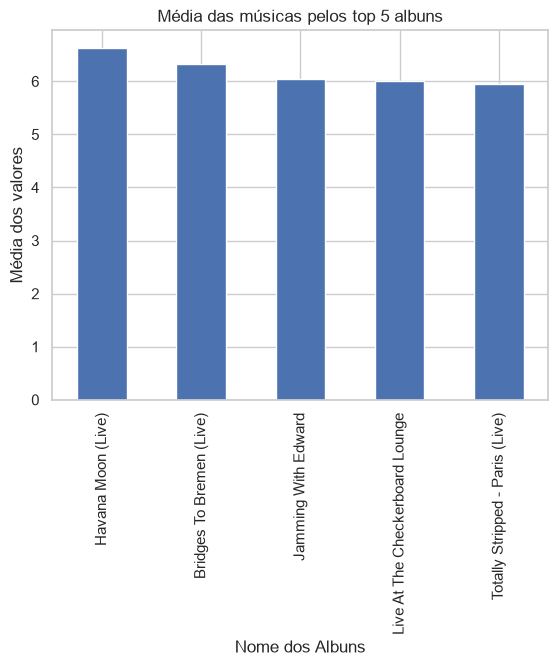

In [77]:
#criando os TOP's 5
df_maior_duracao_musica.head(5).plot(kind="bar")
plt.xlabel("Nome dos Albuns")
plt.ylabel("Média dos valores")
plt.title("Média das músicas pelos top 5 albuns")
plt.show()


<BarContainer object of 10 artists>

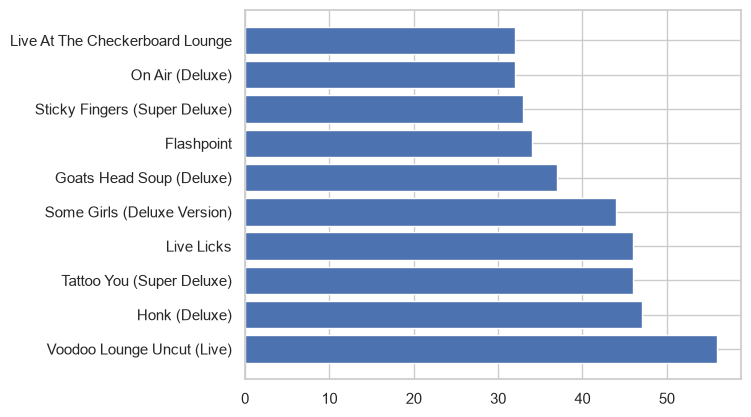

In [78]:
#top albuns em vertical
top_albuns = df_stones['album'].value_counts().head(10)
plt.barh(top_albuns.index, top_albuns.values)

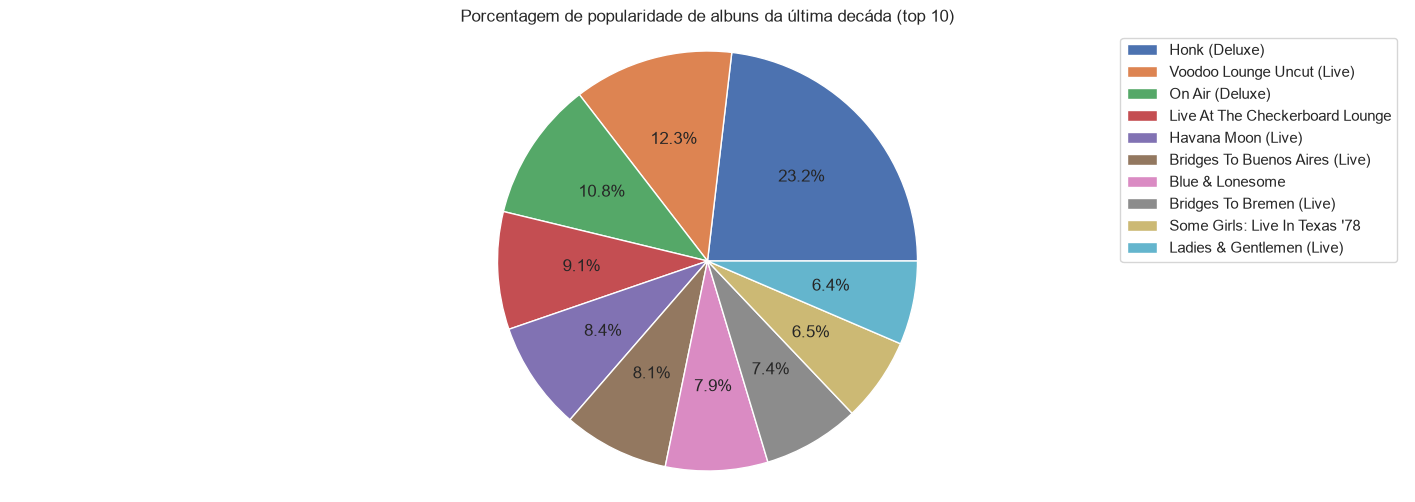

In [79]:
#validando a popularidade deles

df_ultima_decada = df_stones[df_stones['release_date'].between(pd.to_datetime("2011"),pd.to_datetime("2020"))]
df_por_album = df_ultima_decada.groupby("album")["popularity"].sum().sort_values(ascending=False).head(10)
total_popularidade = df_por_album.sum()
df_porcentagem = (df_por_album/total_popularidade)*100
labels = df_porcentagem.index.tolist()
sizes = df_porcentagem.values.tolist()

figura, grafico = plt.subplots(figsize =(18,6))
grafico.pie(sizes, autopct="%1.1f%%")
grafico.axis('equal')
plt.title("Porcentagem de popularidade de albuns da última decáda (top 10)")
plt.legend(labels, loc="best")
plt.show()

OUTLINE - SEABORN

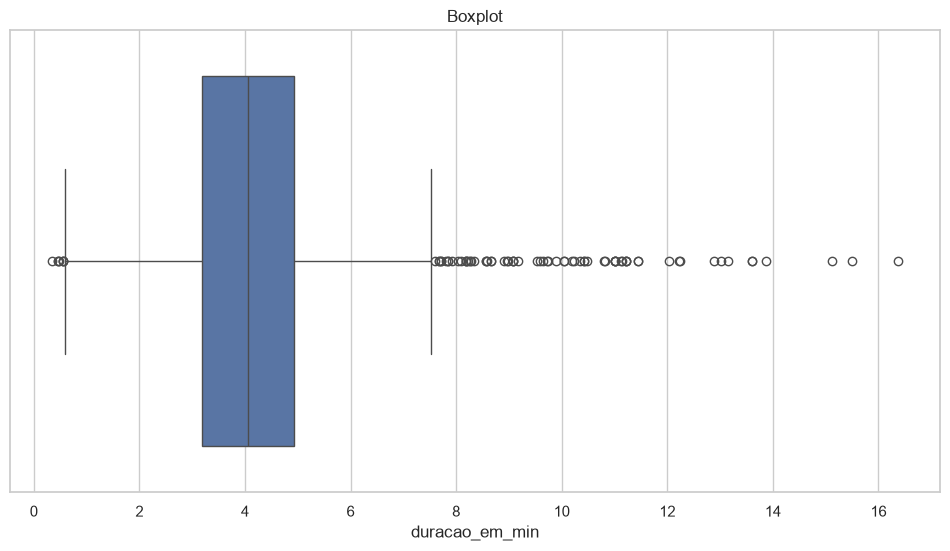

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(figsize=(12,6))
sns.boxplot(x = "duracao_em_min", data = df_stones)
axes.set_title("Boxplot")
plt.show()


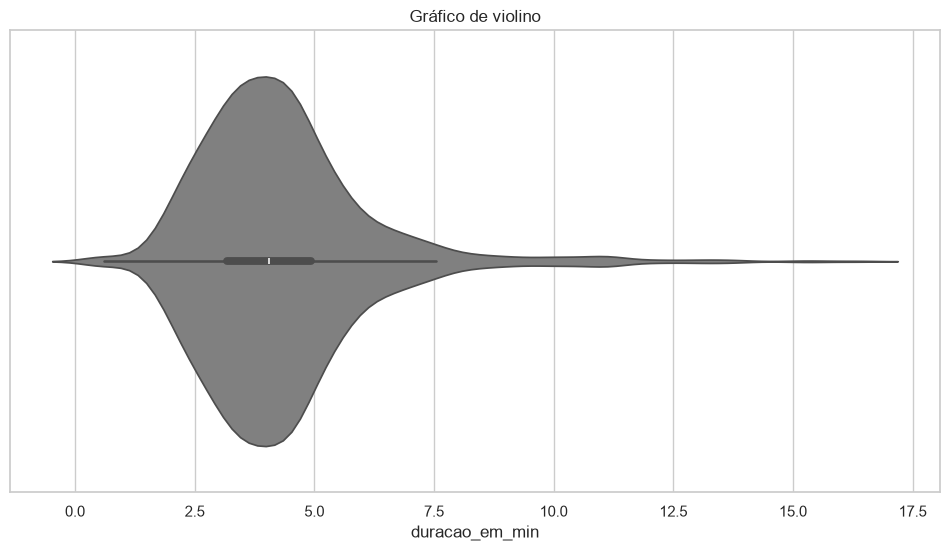

In [81]:
#Gráfico de violino

fig, axes = plt.subplots(figsize=(12,6))
sns.violinplot(x="duracao_em_min", data=df_stones, color ="gray")
axes.set_title("Gráfico de violino")
plt.show()

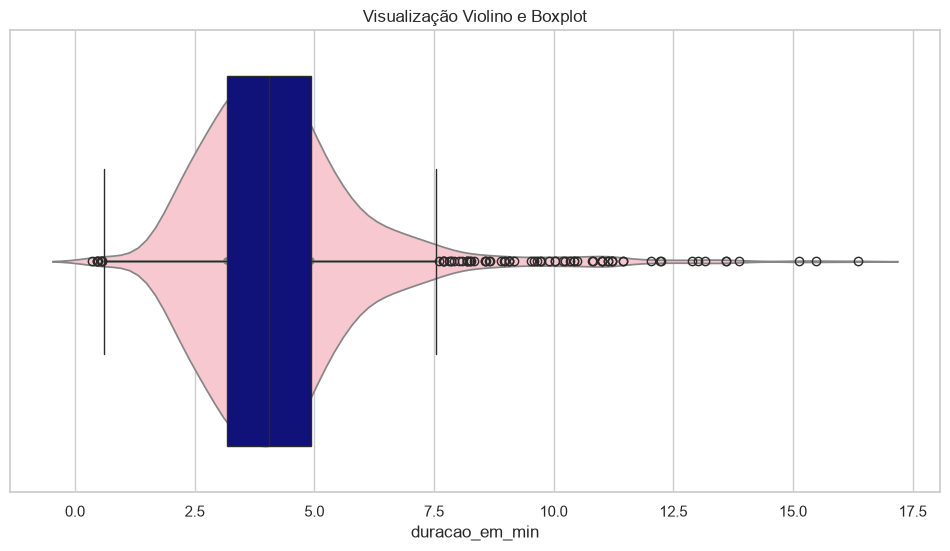

In [82]:
fig, ax = plt.subplots(figsize =(12,6))
sns.violinplot(x="duracao_em_min", data = df_stones, ax = ax, color= "pink")
sns.boxplot(x="duracao_em_min", data = df_stones,  ax = ax, whis=1.5, color="darkblue")
ax.set_title ("Visualização Violino e Boxplot")
plt.show()

In [83]:
#classificando musicas ao vivo

def classificacao_musica_ao_vivo(df_stones):
    if df_stones['liveness'] >= 0.8:
        return True
    else:
        return False

In [84]:
# criando a coluna que faz a classificação do ao vivo

df_stones["ao_vivo"] = df_stones.apply(classificacao_musica_ao_vivo, axis=1)

In [85]:
df_stones.head()

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,duracao_em_min,ao_vivo
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,0.0824,0.463,0.993,0.996000,0.932,-12913.0,0.1100,118001.0,0.0302,33,48640,0.810667,True
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,0.4370,0.326,0.965,0.233000,0.961,-4803.0,0.0759,131455.0,0.3180,34,253173,4.219550,True
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,0.4160,0.386,0.969,0.400000,0.956,-4936.0,0.1150,130066.0,0.3130,34,263160,4.386000,True
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,0.5670,0.369,0.985,0.000107,0.895,-5535.0,0.1930,132994.0,0.1470,32,305880,5.098000,True
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,0.4000,0.303,0.969,0.055900,0.966,-5098.0,0.0930,130533.0,0.2060,32,305106,5.085100,True


In [86]:
#Agrupando o que é ao vivo, contando e separandp 
df_stones.groupby("ao_vivo")["ao_vivo"].count()

ao_vivo
False    1112
True      498
Name: ao_vivo, dtype: int64

In [87]:
#criando as variaveis para armazenar o tipo de gravação
df_gravado_em_estudio = df_stones[df_stones["ao_vivo"] == False]
df_show_ao_vivo = df_stones[df_stones["ao_vivo"] == True]

In [88]:
#trazendo apenas as linhas de gravado em estudio
df_gravado_em_estudio.head()

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,duracao_em_min,ao_vivo
5,Monkey Man - Live,Licked Live In NYC,2022-06-10,6,0.2750,0.340,0.956,0.12500,0.741,-5539.0,0.0915,101628.0,0.125,31,244293,4.071550,False
23,Honky Tonk Women - Live At The El Mocambo 1977,Live At The El Mocambo,2022-05-13,1,0.1620,0.430,0.901,0.01100,0.694,-6215.0,0.0450,112077.0,0.890,32,216546,3.609100,False
25,Hand Of Fate - Live At The El Mocambo 1977,Live At The El Mocambo,2022-05-13,3,0.0654,0.477,0.899,0.03760,0.727,-6189.0,0.0425,129991.0,0.805,29,267866,4.464433,False
26,Route 66 - Live At The El Mocambo 1977,Live At The El Mocambo,2022-05-13,4,0.0975,0.473,0.923,0.00157,0.722,-6204.0,0.0791,144625.0,0.792,30,193653,3.227550,False
28,Crazy Mama - Live At The El Mocambo 1977,Live At The El Mocambo,2022-05-13,6,0.0288,0.447,0.883,0.00554,0.726,-6266.0,0.0371,117604.0,0.556,29,299213,4.986883,False


In [89]:
#trazendo a média das músicas ao vivo e de estúdio

print("Média das músicas ao vivo: ", df_show_ao_vivo["duracao_em_min"].mean())
print("Média das músicas em estudio", df_gravado_em_estudio["duracao_em_min"].mean())

Média das músicas ao vivo:  5.088648962516734
Média das músicas em estudio 3.940451363908873


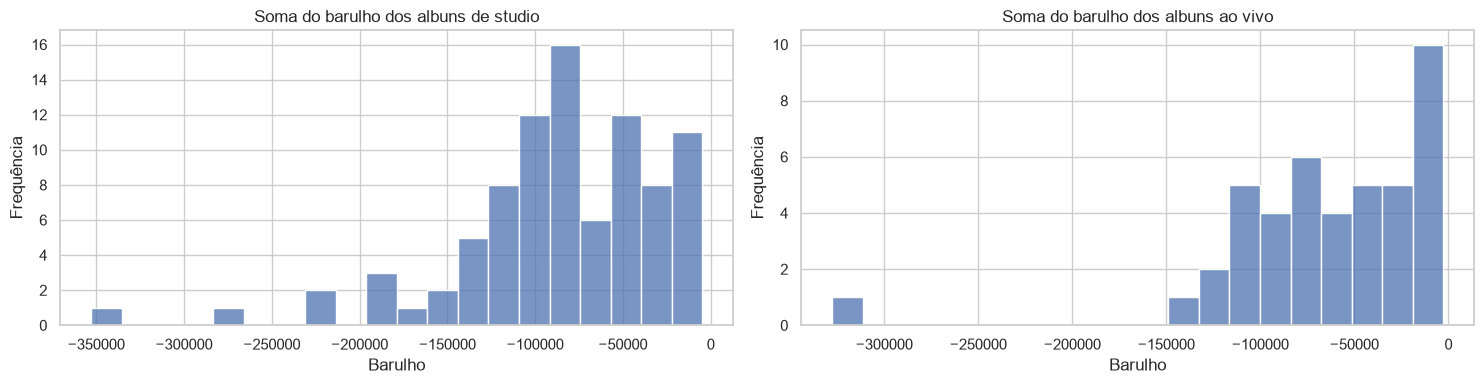

In [90]:
df_studio = df_gravado_em_estudio.groupby("album")["loudness"].sum()
df_ao_vivo = df_show_ao_vivo.groupby("album")["loudness"].sum()

fig, axes = plt.subplots(1, 2, figsize=(15,4))

sns.histplot(data = df_studio, bins = 20, ax=axes[0])
axes[0].set_title("Soma do barulho dos albuns de studio")
axes[0].set_xlabel("Barulho")
axes[0].set_ylabel("Frequência")

sns.histplot(data = df_ao_vivo, bins = 20, ax=axes[1])
axes[1].set_title("Soma do barulho dos albuns ao vivo")
axes[1].set_xlabel("Barulho")
axes[1].set_ylabel("Frequência")
fig.tight_layout()
plt.show()

**GRAFICO DE DENSIDADE**


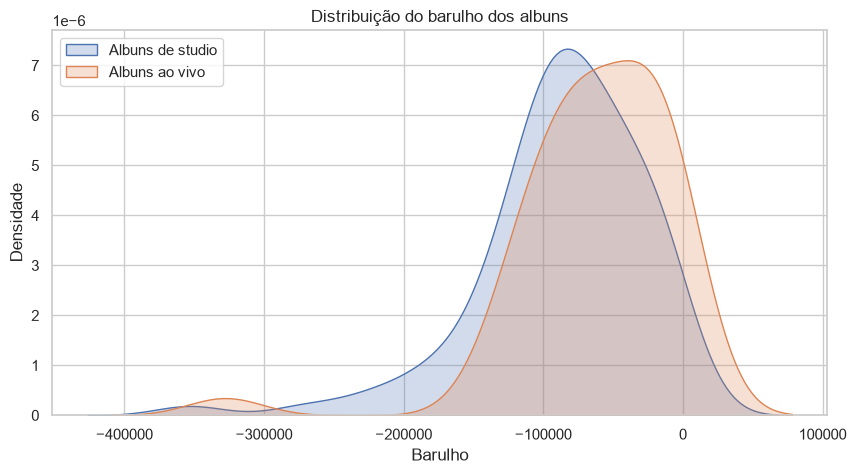

In [91]:
plt.figure(figsize=(10,5))

sns.kdeplot(data = df_studio, label="Albuns de studio", fill=True)
sns.kdeplot(data = df_ao_vivo, label="Albuns ao vivo", fill=True)
plt.title("Distribuição do barulho dos albuns")
plt.xlabel ("Barulho")
plt.ylabel("Densidade")
plt.legend()


TESTE ESTATISTICA - NORMALIDADE ** IMPORTANTE NA VALIDAÇÃO DOS DADOS **

verificando a normalidade dos dados, ou seja, verificando se há muita variação dos valores, no caso há!

In [92]:
# estrutura estudio
from scipy.stats import shapiro

stat, p = shapiro(df_studio)
print("Soma do barulho dos albuns de studio: ")
print("Estatistica de teste: {:.4f}, valor p: {}".format(stat,p))

if p > 0.05:
    print("Não há evidênvcia suficiente para rejeotar a hipótese de normalidade")
else:
    print("A hipótese de normalidade é rejeitada")

    #verificando a normalidade dos dados, ou seja, verificando se há muita variação dos valores, no caso há!

Soma do barulho dos albuns de studio: 
Estatistica de teste: 0.8958, valor p: 3.2961810670595794e-06
A hipótese de normalidade é rejeitada


In [93]:
# estrutura estuao vivod
from scipy.stats import shapiro

stat, p = shapiro(df_ao_vivo)
print("Soma do barulho dos albuns ao vivo: ")
print("Estatistica de teste: {:.4f}, valor p: {}".format(stat,p))

if p > 0.05:
    print("Não há evidênvcia suficiente para rejeotar a hipótese de normalidade")
else:
    print("A hipótese de normalidade é rejeitada")

    #verificando a normalidade dos dados, ou seja, verificando se há muita variação dos valores, no caso há!

Soma do barulho dos albuns ao vivo: 
Estatistica de teste: 0.7913, valor p: 2.3506009205064346e-06
A hipótese de normalidade é rejeitada


In [94]:
from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(df_studio.sample(len(df_studio)), df_ao_vivo.sample(len(df_ao_vivo)), alternative="less")
print("Estatística de teste U: ", stat)
print("Valor p: ", p)

alpha = 0.05
if p < alpha:
    print("Diferença estatisticamente significante")
else:
    print("Não há diferença estatisticamente significante")


Estatística de teste U:  1367.0
Valor p:  0.0050727361177996585
Diferença estatisticamente significante


ANÁLISE DE CORRELAÇÃO - Avaliando se as músicas são um pouco mais tristes ou felizes 

In [95]:
#Avaliando se as músicas são um pouco mais tristes ou felizes 
# no caso eu peguei cada album e fiz uma media entre as musicas e dentro da quantidade de album eu tirei o que é positivo e negativo

media_por_album = df_stones.groupby("album")["valence"].mean().reset_index()

media_por_album = media_por_album.rename(columns={"valence": "media_valence"})

media_por_album["sentimento"] = ["positivo" if v > 0.6 else "negativo" for v in media_por_album["media_valence"]]

media_por_album.groupby("sentimento")["sentimento"].count()


sentimento
negativo    38
positivo    52
Name: sentimento, dtype: int64

In [96]:
#criação do df na linha de código anterior
media_por_album.head(2)

,album,media_valence,sentimento
0,12 X 5,0.704000,positivo
1,12 x 5,0.689917,positivo


In [118]:
#juntando o dataset media_por_album no meu dataset original

df_resultado_final =pd.merge(df_stones, media_por_album, on = "album")
df_resultado_final.head()

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,duracao_em_min,ao_vivo,media_valence,sentimento
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,0.0824,0.463,0.993,0.996000,0.932,-12913.0,0.1100,118001.0,0.0302,33,48640,0.810667,True,0.27117,negativo
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,0.4370,0.326,0.965,0.233000,0.961,-4803.0,0.0759,131455.0,0.3180,34,253173,4.219550,True,0.27117,negativo
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,0.4160,0.386,0.969,0.400000,0.956,-4936.0,0.1150,130066.0,0.3130,34,263160,4.386000,True,0.27117,negativo
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,0.5670,0.369,0.985,0.000107,0.895,-5535.0,0.1930,132994.0,0.1470,32,305880,5.098000,True,0.27117,negativo
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,0.4000,0.303,0.969,0.055900,0.966,-5098.0,0.0930,130533.0,0.2060,32,305106,5.085100,True,0.27117,negativo


-----> MATRIZ DE CORRELAÇÃO

In [ ]:

matriz_correlacao = df_resultado_final.select_dtypes(include=['number']).corr()
correlacao_sentimento = matriz_correlacao['media_valence']
display(correlacao_sentimento)

track_number       -0.115007
acousticness        0.015491
danceability        0.492945
energy             -0.347447
instrumentalness    0.133741
liveness           -0.571749
loudness           -0.229543
speechiness        -0.416005
tempo              -0.028887
valence             0.603258
popularity          0.100509
duration_ms        -0.309499
duracao_em_min     -0.309499
media_valence       1.000000
Name: media_valence, dtype: float64

<Axes: >

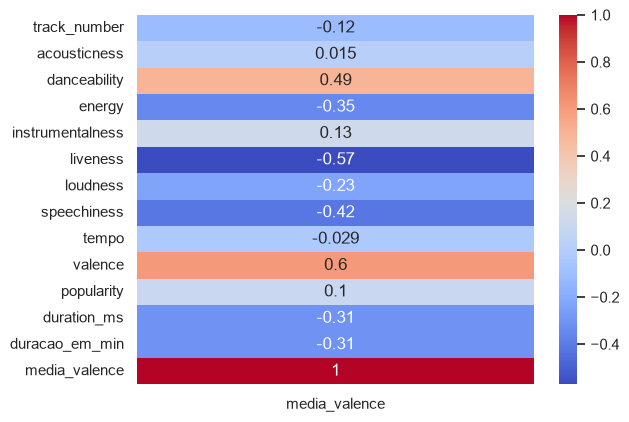

In [112]:
sns.heatmap(correlacao_sentimento.to_frame(), annot=True,  cmap="coolwarm" )

GRÁFICO DISPERSÃO

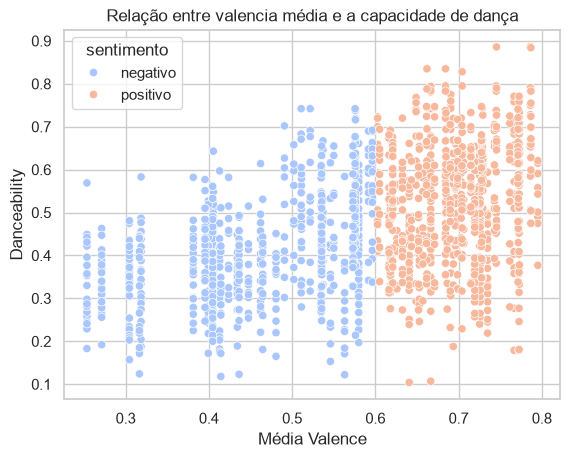

In [120]:
sns.scatterplot(x="media_valence", y="danceability", hue="sentimento", data=df_resultado_final,palette="coolwarm")
plt.xlabel("Média Valence")
plt.ylabel("Danceability")
plt.title("Relação entre valencia média e a capacidade de dança")
plt.show()

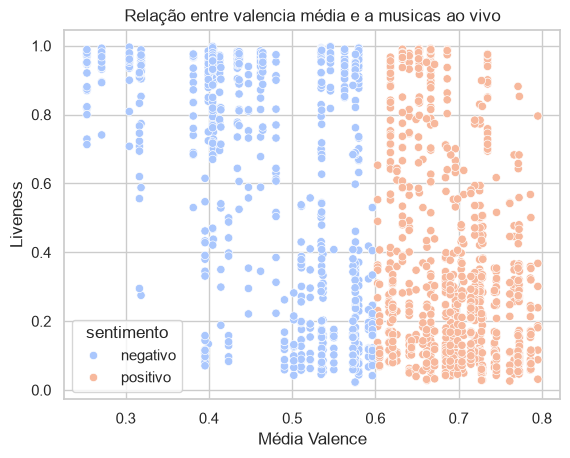

In [ ]:
#comportamneto de uma correlção negativa, não tem uma realção entre as variaveis
sns.scatterplot(x="media_valence", y="liveness", hue="sentimento", data= df_resultado_final, palette="coolwarm")
plt.xlabel("Média Valence")
plt.ylabel("Liveness")
plt.title("Relação entre valencia média e a musicas ao vivo")
plt.show()
